In [1]:
!git clone https://github.com/quark28/miniml.git
%cd miniml

Cloning into 'miniml'...
remote: Enumerating objects: 218, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 218 (delta 9), reused 10 (delta 9), pack-reused 204 (from 1)
Receiving objects: 100% (218/218), 1.50 MiB | 10.61 MiB/s, done.
Resolving deltas: 100% (104/104), done.
/content/miniml


In [2]:
from miniml.cluster.kmeans import KMeans

In [9]:
from sklearn.cluster import KMeans as SklearnKMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import adjusted_rand_score
import pandas as pd
import numpy as np

# 1. Генерируем датасет средней сложности (кластеры достаточно плотные, но не изолированные до идеала)
X, y_true = make_blobs(n_samples=400, centers=4, n_features=2, cluster_std=0.65, random_state=42)
K = 4

# 2. Обучаем модель (RNG управляется через np.random внутри твоего класса)
my_kmeans = KMeans(random_state=42)
my_labels = my_kmeans.fit_predict(X, K=K, metric='euclid', init_type='kmeans++')

# Считаем инерцию (WCSSE) вручную для центроидов
my_inertia = np.sum((X - my_kmeans.coord_centers[my_labels]) ** 2)

# 3. Обучаем Sklearn (RNG управляется внутренним генератором Cython)
sk_kmeans = SklearnKMeans(n_clusters=K, init='k-means++', n_init=1, random_state=42, max_iter=100, tol=1e-4)
sk_labels = sk_kmeans.fit_predict(X)
sk_inertia = sk_kmeans.inertia_

# 4. Метрики сходимости
# Сходство разбиений между моделью и истинными метками
my_vs_true_ari = adjusted_rand_score(y_true, my_labels)
# Сходство разбиений между sklearn и истинными метками
sk_vs_true_ari = adjusted_rand_score(y_true, sk_labels)

# Главная метрика: Сходство разбиения модели и sklearn между собой
models_similarity_ari = adjusted_rand_score(my_labels, sk_labels)

# 5. Вывод логов
df_metrics = pd.DataFrame({
    'Параметр': ['Inertia (WCSSE)', 'ARI vs Ground Truth', 'Взаимное сходство (ARI между моделями)'],
    'Miniml': [f"{my_inertia:.4f}", f"{my_vs_true_ari:.4f}", "-"],
    'Sklearn (k-means++)': [f"{sk_inertia:.4f}", f"{sk_vs_true_ari:.4f}", "-"]
})

print("=" * 75)
print("СРАВНЕНИЕ КЛАССОВ ПРИ НЕЗАВИСИМОЙ ИНИЦИАЛИЗАЦИИ ИЗ РАЗНЫХ RNG СТРИМОВ")
print("=" * 75)
print(df_metrics.to_string(index=False))
print("-" * 75)
print(f"Индекс сходства разбиений обеих моделей друг с другом: {models_similarity_ari:.4f}")
print("=" * 75)

# Жесткий инжиниринговый критерий: взаимный ARI должен стремиться к 1.0 (+- погрешность на пару точек на границах)
assert models_similarity_ari >= 0.98, f"Модели сошлись к принципиально разным разбиениям! ARI = {models_similarity_ari}"
print("Тест пройден: Несмотря на разные стартовые центроиды, модели сошлись к идентичной топологии кластеров.")

СРАВНЕНИЕ КЛАССОВ ПРИ НЕЗАВИСИМОЙ ИНИЦИАЛИЗАЦИИ ИЗ РАЗНЫХ RNG СТРИМОВ
                              Параметр   Miniml Sklearn (k-means++)
                       Inertia (WCSSE) 323.8540            323.8540
                   ARI vs Ground Truth   1.0000              1.0000
Взаимное сходство (ARI между моделями)        -                   -
---------------------------------------------------------------------------
Индекс сходства разбиений обеих моделей друг с другом: 1.0000
Тест пройден: Несмотря на разные стартовые центроиды, модели сошлись к идентичной топологии кластеров.


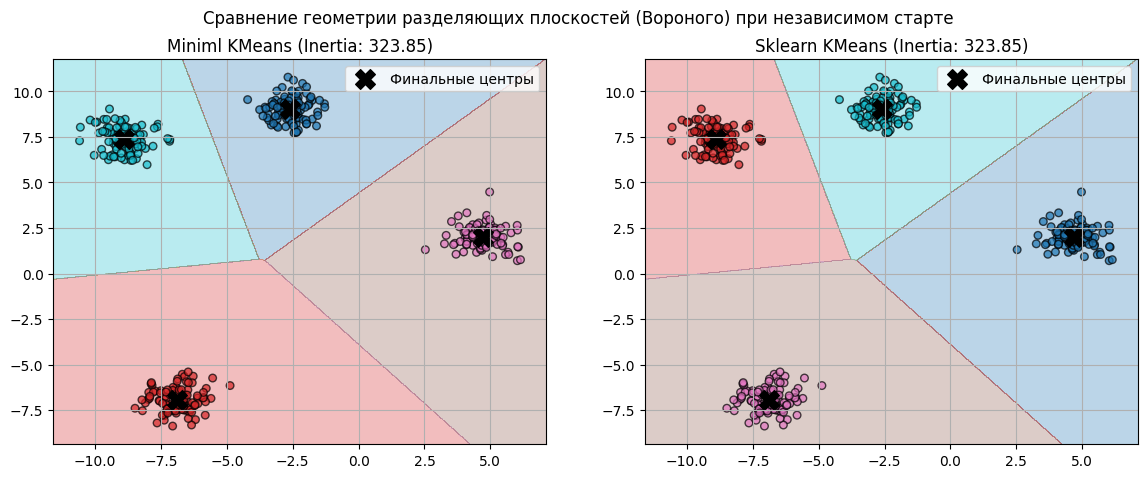

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# Сетка для отрисовки Voronoi-границ
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
grid_points = np.c_[xx.ravel(), yy.ravel()]

plt.subplot(1, 2, 1)
Z_my = my_kmeans.predict(grid_points, K=K, metric='euclid')
Z_my = Z_my.reshape(xx.shape)
plt.contourf(xx, yy, Z_my, alpha=0.3, cmap='tab10')
plt.scatter(X[:, 0], X[:, 1], c=my_labels, cmap='tab10', alpha=0.7, edgecolors='k', s=30)
plt.scatter(my_kmeans.coord_centers[:, 0], my_kmeans.coord_centers[:, 1], c='black', marker='X', s=200, label='Финальные центры')
plt.title(f"Miniml KMeans (Inertia: {my_inertia:.2f})")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
Z_sk = sk_kmeans.predict(grid_points)
Z_sk = Z_sk.reshape(xx.shape)
plt.contourf(xx, yy, Z_sk, alpha=0.3, cmap='tab10')
plt.scatter(X[:, 0], X[:, 1], c=sk_labels, cmap='tab10', alpha=0.7, edgecolors='k', s=30)
plt.scatter(sk_kmeans.cluster_centers_[:, 0], sk_kmeans.cluster_centers_[:, 1], c='black', marker='X', s=200, label='Финальные центры')
plt.title(f"Sklearn KMeans (Inertia: {sk_inertia:.2f})")
plt.legend()
plt.grid(True)

plt.suptitle("Сравнение геометрии разделяющих плоскостей (Вороного) при независимом старте", fontsize=12)
plt.show()